In [2]:
import fitz
import requests
import io
import pickle
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import re
from bs4 import BeautifulSoup
import pandas as pd
import nltk
import random

In [3]:
doc = fitz.open("../data/test_pdf+xml/Trevisanus1567_De_alchemia_MDZ_MBS.pdf")

In [4]:
doc.page_count

24

In [5]:
p = doc.load_page(14)

In [6]:
p

page 14 of ../data/test_pdf+xml/Trevisanus1567_De_alchemia_MDZ_MBS.pdf

In [7]:
pix = p.get_pixmap()

In [8]:
pix.width

1159

In [9]:
pix.height

1740

In [10]:
np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...

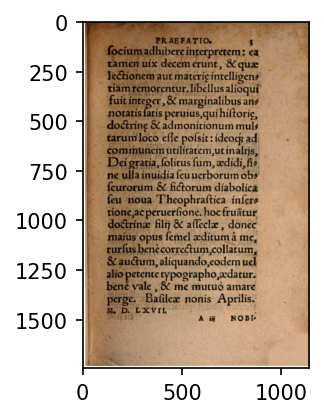

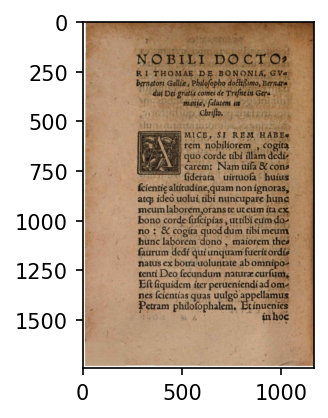

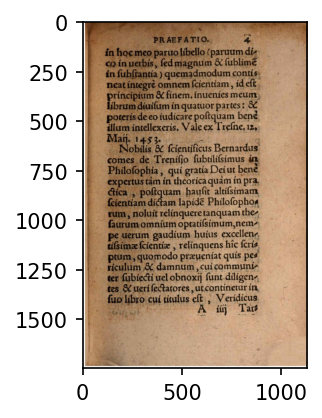

In [13]:
for p in [p for p in doc][5:8]:
    pix = p.get_pixmap()
    np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
    fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
    ax.imshow(np_array)
    plt.show()

In [14]:
print(p.get_text())

PRAEFATIO. 4
in hoc meo paruo libello (paruum di¬
co in uerbis, sed magnum & sublimen
in substantia) quemadmodum conti¬
neat integre omnem scientiam, id est
principium & finem, inuenies meum
librum diuisum in quatuor partes: &
poteris de eo iudicare postquam benè
illum intellexeris. Vale ex Tresne. 12.
Maij. 1453.
Nobilis & scientificus Bernardus
comes de Trenisio subtilissimus in
Philosophia, qui gratia Dei ut bene
expertus tàm in theorica quàm in pra¬
ctica, postquam hausit altissimam
scientiam dictam lapidem Philosopho¬
rum, noluit relinquere tanquam the¬
saurum omnium optatissimum, nem¬
pe uerum gaudium huius excellen¬
tissimae scientiae, relinquens hîc scri¬
ptum, quomodo praeueniat quis pe¬
riculum & damnum, cui communi¬
ter subiecti uel obnoxij sunt diligen¬
tes & ueri sectatores, ut continetur in
suo libro cui titulus est, Veridicus
A iiij Tar¬



In [15]:
textblocks = p.get_text_blocks() # ("blocks")
textblocks

[(350.8800048828125,
  102.96005249023438,
  857.8248901367188,
  107.76004791259766,
  'PRAEFATIO. 4\n',
  0,
  0),
 (102.4800033569336,
  167.76010131835938,
  878.9548950195312,
  172.5601043701172,
  'in hoc meo paruo libello (paruum di¬\n',
  1,
  0),
 (105.36000061035156,
  221.54409790039062,
  886.8265380859375,
  226.46409606933594,
  'co in uerbis, sed magnum & sublimen\n',
  2,
  0),
 (112.08000183105469,
  274.5840148925781,
  888.4375,
  279.5040283203125,
  'in substantia) quemadmodum conti¬\n',
  3,
  0),
 (115.91999816894531,
  329.0400085449219,
  884.2129516601562,
  333.8399963378906,
  'neat integre omnem scientiam, id est\n',
  4,
  0),
 (121.68000030517578,
  383.2799987792969,
  895.36767578125,
  388.0799865722656,
  'principium & finem, inuenies meum\n',
  5,
  0),
 (122.63999938964844,
  436.5840148925781,
  889.7797241210938,
  441.5040283203125,
  'librum diuisum in quatuor partes: &\n',
  6,
  0),
 (133.1999969482422,
  491.0400085449219,
  892.3779296875,


In [16]:
central_textblocks = textblocks[2:-1]
len(central_textblocks)

23

In [17]:
len(textblocks)

26

In [18]:
central_textblocks = textblocks[2:-1]
avg_width = np.mean([rect[2] - rect[0] for rect in central_textblocks])
avg_left_x = np.mean([rect[0] for rect in central_textblocks])
avg_right_x = np.mean([rect[2] for rect in central_textblocks])

avg_charn = sum([len(textblock) for textblock in central_textblocks]) / len(central_textblocks)
avg_charn_density = avg_charn / avg_width

In [19]:
def check_header(textblock, avg_width, avg_left_x, header_width_proportion_max=0.8, header_left_x_ratio_min=1.2, header_uppercase_proportion_min = 0.6, header_digits_proportion_min = 0.6):
    width_ratio = (textblock[2] - textblock[0])  / avg_width # thinner than average line
    left_x_ratio = textblock[0] / avg_left_x # more right than average line
    textblock_text = textblock[4].replace("\n", "")
    uppercase_ratio = sum(1 for char in textblock_text if char.isupper()) / len(textblock_text)
    digits_ratio =  sum(1 for char in textblock_text if char.isdigit()) / len(textblock_text)
    if sum([(width_ratio < header_width_proportion_max),(left_x_ratio > header_left_x_ratio_min),(uppercase_ratio > header_uppercase_proportion_min),(digits_ratio > header_digits_proportion_min)]) >= 2: # if first
        return True
    else:
        return False
def check_footer(textblock, avg_width, avg_left_x, avg_right_x, footer_width_proportion_max=0.5, footer_left_x_ratio_min=1.2):
    width_ratio = (textblock[2] - textblock[0])  / avg_width # thinner than average line
    left_x_ratio = textblock[0] / avg_left_x # more right than average line
    right_x_ratio = textblock[2] / avg_right_x # more right than average line
    textblock_text = textblock[4].replace("\n", "")
    digits_ratio =  sum(1 for char in textblock_text if char.isdigit()) / len(textblock_text)
    if sum([(width_ratio < footer_width_proportion_max), (left_x_ratio > 1.2),  (0.9 < right_x_ratio < 1.1),(digits_ratio > 0.6)]) >= 2: # if first
        return True
    else:
        return False

def check_title(textblock, avg_charn_density, textblock_char_density_ratio_max=0.75):
    textblock_char_density = len(textblock[4]) / (textblock[2] - textblock[0])
    textblock_char_density_ratio = textblock_char_density / avg_charn_density
    if textblock_char_density_ratio < textblock_char_density_ratio_max:
        return True
    else:
        return False


In [35]:
patch_color_dict = {"title" : "green",
                    "header" : "red",
                    "footer" : "orange",
                    "margin" : "yellow",
                     "text" : "white",
}

def plot_patch(textblock_annotated, patch_color_dict):
   color = patch_color_dict[textblock_annotated[5]]
   patch = patches.Rectangle((textblock_annotated[0], textblock_annotated[1]),  # Bottom left corner
                              textblock_annotated[2] - textblock_annotated[0],  # Width
                              textblock_annotated[3] - textblock_annotated[1],  # Height
                              linewidth=0.3, edgecolor=color, facecolor='none')
   ax.add_patch(patch) # draw candidate textblocks in black


params = {"header_width_proportion_max" : 0.8,
          "header_left_x_ratio_min" : 1.2,
          "header_uppercase_proportion_min" : 0.6,
          "header_digits_proportion_min" : 0.6,
          "footer_width_proportion_max" : 0.5,
          "footer_left_x_ratio_min" : 1.2,
          "textblock_char_density_ratio_max" : 0.75}

def get_page_annots(textblocks,
                    patch_color_dict=patch_color_dict,
                    params=params):
    textblocks_enumerated = [[el[0], el[1], el[2], el[3], el[4], n] for n, el in enumerate(textblocks)]
    textblocks = sorted(textblocks_enumerated, key=lambda x: x[1])
    textblocks = [[el[0], el[1], el[2], el[3], el[4], el[5], n] for n, el in enumerate(textblocks)]
    central_textblocks = textblocks[2:-1]
    avg_width = np.mean([rect[2] - rect[0] for rect in central_textblocks])
    avg_left_x = np.mean([rect[0] for rect in central_textblocks])
    avg_right_x = np.mean([rect[2] for rect in central_textblocks])
    try:
        avg_charn = sum([len(textblock[4]) for textblock in central_textblocks]) / len(central_textblocks)
        avg_charn_density = avg_charn / avg_width
    except:
        avg_charn_density = 0
    textblocks_annotated = []
    for textblock in textblocks:
        annot = "text"
        if textblock[6] in [0,1]:
            if check_header(textblock,
                            avg_width,
                            avg_left_x,
                            header_width_proportion_max=params["header_width_proportion_max"],
                            header_left_x_ratio_min=params["header_left_x_ratio_min"],
                            header_uppercase_proportion_min=params["header_uppercase_proportion_min"],
                            header_digits_proportion_min=params["header_digits_proportion_min"]):
                annot = "header"
        if textblock[6] == len(textblocks) -1:
            if check_footer(textblock,
                            avg_width,
                            avg_left_x,
                            avg_right_x,
                            footer_width_proportion_max=params["footer_width_proportion_max"],
                            footer_left_x_ratio_min=params["footer_left_x_ratio_min"]):
                annot = "footer"
        if annot != "header" and annot != "footer":
            if check_title(textblock,
                           avg_charn_density,
                           textblock_char_density_ratio_max=params["textblock_char_density_ratio_max"]):
                annot = "title"
        textblocks_annotated.append([textblock[0], textblock[1], textblock[2], textblock[3], textblock[4], textblock[5], textblock[6], annot])
    textblocks_annotated_reordered = [[el[0], el[1], el[2], el[3], el[4], el[7]] for el in sorted(textblocks_annotated, key=lambda x: x[5])]
    # marginalia to full annotations
    margin_in_progress = False
    for textblock in textblocks_annotated_reordered:
        if "[M]" in textblock[4]:  # Check for the opening marginalia tag
            textblock[4] = textblock[4].replace("[M]", "")  # Remove the tag
            margin_in_progress = True  # Marginalia started

        if margin_in_progress:  # If within a marginalia block
            textblock[5] = "margin"  # Annotate as margin

        if "[/M]" in textblock[4]:  # Check for the closing marginalia tag
            textblock[4] = textblock[4].replace("[/M]", "")  # Remove the tag
            margin_in_progress = False  # Marginalia ended
        plot_patch(textblock, patch_color_dict)
    return textblocks_annotated_reordered

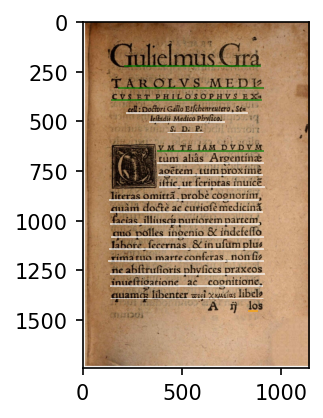

In [41]:
p = doc.load_page(3)
pix = p.get_pixmap()
np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
textblocks = p.get_text_blocks()
params = {"header_width_proportion_max" : 0.8,
          "header_left_x_ratio_min" : 1.2,
          "header_uppercase_proportion_min" : 0.6,
          "header_digits_proportion_min" : 0.6,
          "footer_width_proportion_max" : 0.5,
          "footer_left_x_ratio_min" : 1.2,
          "textblock_char_density_ratio_max" : 0.75}
page_textblocks_annotated = get_page_annots(textblocks,
                    patch_color_dict=patch_color_dict,
                    params=params)
ax.imshow(np_array)
plt.show()

In [22]:
page_textblocks_annotated

[[209.0399932861328,
  215.27999877929688,
  894.053955078125,
  220.0800018310547,
  'Gulielmus Gra¬\n',
  'title'],
 [175.44000244140625,
  326.9039611816406,
  910.0022583007812,
  331.823974609375,
  'TAROLVS MEDI¬\n',
  'title'],
 [143.75999450683594,
  388.5600280761719,
  899.9873657226562,
  393.3600158691406,
  'CVS ET PHILOSOPHVS EX¬\n',
  'title'],
 [215.75999450683594,
  452.3999938964844,
  825.4468994140625,
  457.1999816894531,
  'cell: Doctori Gallo Etschenreutero, Se¬\n',
  'text'],
 [331.67999267578125,
  499.6800231933594,
  710.8863525390625,
  504.4800109863281,
  'lestadij Medico Physico.\n',
  'text'],
 [425.5199890136719,
  551.2799682617188,
  603.81201171875,
  556.0800170898438,
  'S. D. P.\n',
  'text'],
 [372.9599914550781,
  644.6640014648438,
  909.0391845703125,
  649.583984375,
  'CVM TE IAM DVDVM\n',
  'text'],
 [372.0,
  703.1998901367188,
  909.5879516601562,
  707.9999389648438,
  'tum aliâs Argentinae\n',
  'text'],
 [378.7200012207031,
  765.35992

In [31]:
# random sample of 8 pages from the doc
random.seed(0)
pages_sample = random.sample([p for p in doc], min(8, len(doc)))

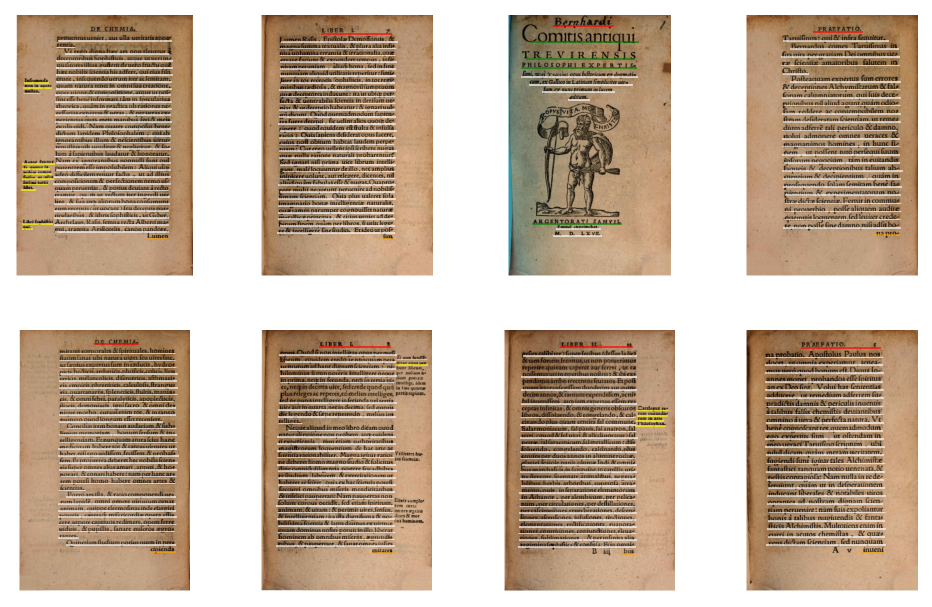

In [48]:
random.seed(0)
pages_sample = random.sample([p for p in doc], min(8, len(doc)))
pages_textblocks_annotated = []
fig, axs = plt.subplots(2,4, figsize=(8, 5), dpi=150)
for p, ax in zip(pages_sample, axs.ravel()):
        pix = p.get_pixmap()
        np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
        textblocks = p.get_text_blocks()
        pages_textblocks_annotated.append(get_page_annots(textblocks,
                    patch_color_dict, params=params))
        ax.axis('off')
        ax.imshow(np_array)

In [46]:
def test_doc_annotations(doc,params):
    random.seed(0)
    pages_sample = random.sample([p for p in doc], min(8, len(doc)))
    pages_textblocks_annotated = []
    fig, axs = plt.subplots(2,4, figsize=(8, 5), dpi=150)
    for p, ax in zip(pages_sample, axs.ravel()):
        pix = p.get_pixmap()
        np_array = np.frombuffer(pix.samples, dtype=np.uint8).reshape(pix.height, pix.width, pix.n) # if you need an image matrix...
        textblocks = p.get_text_blocks()
        pages_textblocks_annotated.append(get_page_annots(textblocks,
                    patch_color_dict, params=params))
        ax.axis('off')
        ax.imshow(np_array)

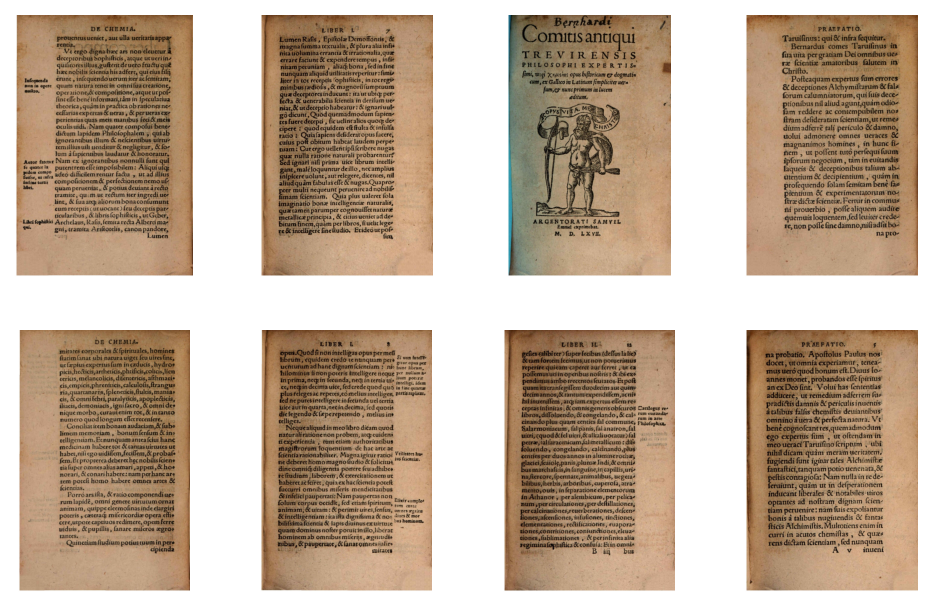

In [47]:
params = {"header_width_proportion_max" : 0.8,
          "header_left_x_ratio_min" : 1.2,
          "header_uppercase_proportion_min" : 0.6,
          "header_digits_proportion_min" : 0.6,
          "footer_width_proportion_max" : 0.5,
          "footer_left_x_ratio_min" : 1.2,
          "textblock_char_density_ratio_max" : 0.75}
test_doc_annotations(doc, params)

In [102]:
pages_textblocks_annotated[-1]

[[377.5199890136719,
  112.08004760742188,
  861.5700073242188,
  116.88004302978516,
  'LIBER II. 12\n',
  'header'],
 [129.83999633789062,
  172.32003784179688,
  888.1253051757812,
  177.1200408935547,
  'gesies (alibi ter) super fecibus ([F]dessus la lie[/F])\n',
  'text'],
 [122.63999938964844,
  308.3999938964844,
  886.8301391601562,
  313.1999816894531,
  'possemus uti in operibus nostris: & ibi ex¬\n',
  'text'],
 [119.04000091552734,
  397.9200134277344,
  885.9032592773438,
  402.7200012207031,
  'quam ita transegissem duodecim aut quin¬\n',
  'text'],
 [116.63999938964844,
  489.6000671386719,
  885.3707885742188,
  494.4000549316406,
  'hil inuenissem, atque iam expertus essem re¬\n',
  'text'],
 [111.83999633789062,
  579.8400268554688,
  878.93603515625,
  584.6400756835938,
  'libros, dissoluendo, & congelando, & cal¬\n',
  'text'],
 [111.83999633789062,
  627.8400268554688,
  878.203125,
  632.6400756835938,
  'cinando plus quam centies sal commune,\n',
  'text'],
 [11

In [106]:
flattext = ""
for p_textblocks in pages_textblocks_annotated:
    for textblock in p_textblocks:
        if textblock[5] == "text":
            flattext += textblock[4]

In [107]:
print(flattext)

Comitis antiqui
TREVIRENSIS
PHILOSOPHI EXPERTIS¬
simi, περὶ χημείας opus historicum & dogmati¬
cum, ex Gallico in Latinum simpliciter uer¬
sum, & nunc primum in lucem
aeditum.
ARGENTORATI SAMVEL
Emmel exprimebat.
M. D. LXVII.
Gulielmus Gra¬
TAROLVS MEDI¬
CVS ET PHILOSOPHVS EX¬
cell: Doctori Gallo Etschenreutero, Se¬
lestadij Medico Physico.
S. D. P.
CVM TE IAM DVDVM
tum aliâs Argentinae
agentem, tùm proximè
istic, ut scriptas inuicem
literas omittam, probè cognorim
quàm doctè ac curiosè medicinam
facias, illiusque puriorem partem
quo polles ingenio & indefesso
labore, secernas, & in usum plu¬
rima tuo marte conferas, non si¬
ne abstrusioris physices praxeos
inuestigatione ac cognitione,
quamque libenter περὶ χημειασ libel¬
los euoluas, sineque impostura uel
inani iactantia res ipsas ostendas,
conferas cùm alijs artis amicis, &
communices: uisum mihi est huc
eius rarissimae artis & scientiae
praecipuum & multis alijs since¬
riorem libellum, (cuius author
alios suo exemplo ac periculo
ca